In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

In [22]:
df = pd.read_csv("fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [23]:
df = pd.read_csv("fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [24]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [25]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [26]:
X = df.drop(['isFraud', 'step', 'isFlaggedFraud'], axis=1, errors='ignore')
y = df['isFraud']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")

    print(classification_report(y_true, y_pred))

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(name)
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha='center', va='center')

    plt.show()


===== Random Forest (Baseline) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.96      0.80      0.87      1620

    accuracy                           1.00   1272524
   macro avg       0.98      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

Accuracy : 0.9997
Precision: 0.9612
Recall   : 0.7951
F1 Score : 0.8703


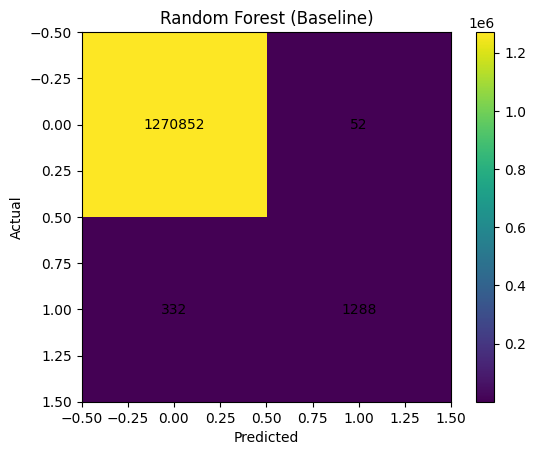

['rf_baseline.pkl']

In [29]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

evaluate_model("Random Forest (Baseline)", y_test, rf_pred)

joblib.dump(rf_model, "rf_baseline.pkl")


===== XGBoost (Baseline) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.96      0.76      0.85      1620

    accuracy                           1.00   1272524
   macro avg       0.98      0.88      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524

Accuracy : 0.9997
Precision: 0.9574
Recall   : 0.7623
F1 Score : 0.8488


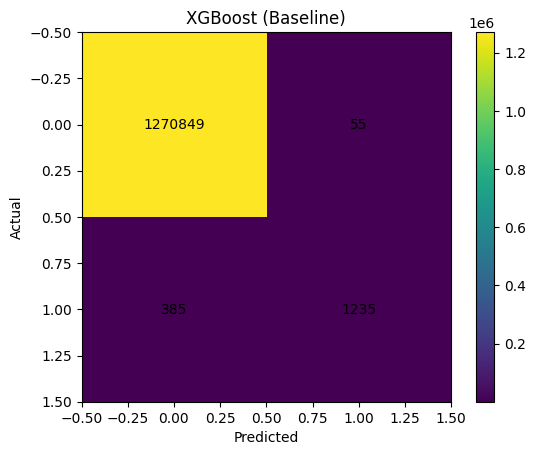

['xgb_baseline.pkl']

In [30]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

evaluate_model("XGBoost (Baseline)", y_test, xgb_pred)

joblib.dump(xgb_model, "xgb_baseline.pkl")

In [31]:
print("Problem: Class imbalance → poor fraud detection")

Problem: Class imbalance → poor fraud detection


In [32]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

isFraud
0    5083503
1    5083503
Name: count, dtype: int64



===== Random Forest (SMOTE) =====
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270904
           1       0.08      0.99      0.14      1620

    accuracy                           0.98   1272524
   macro avg       0.54      0.99      0.57   1272524
weighted avg       1.00      0.98      0.99   1272524

Accuracy : 0.9849
Precision: 0.0771
Recall   : 0.9938
F1 Score : 0.1431


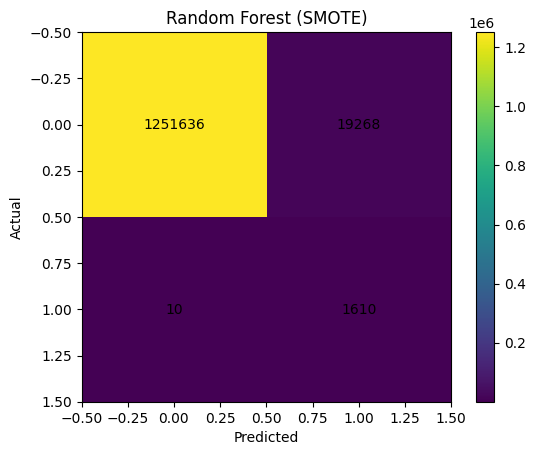

['rf_smote.pkl']

In [33]:
rf_model_smote = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model_smote.fit(X_train_res, y_train_res)

rf_pred_smote = rf_model_smote.predict(X_test)

evaluate_model("Random Forest (SMOTE)", y_test, rf_pred_smote)

joblib.dump(rf_model_smote, "rf_smote.pkl")


===== XGBoost (SMOTE) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.27      1.00      0.42      1620

    accuracy                           1.00   1272524
   macro avg       0.63      1.00      0.71   1272524
weighted avg       1.00      1.00      1.00   1272524

Accuracy : 0.9965
Precision: 0.2657
Recall   : 0.9957
F1 Score : 0.4195


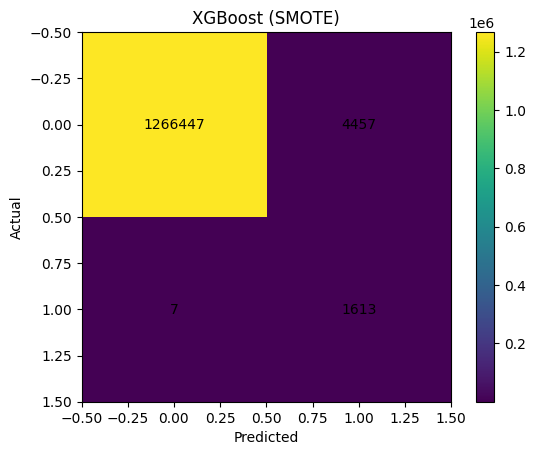

['xgb_smote.pkl']

In [34]:
xgb_model_smote = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model_smote.fit(X_train_res, y_train_res)

xgb_pred_smote = xgb_model_smote.predict(X_test)

evaluate_model("XGBoost (SMOTE)", y_test, xgb_pred_smote)

joblib.dump(xgb_model_smote, "xgb_smote.pkl")


===== XGBoost (SMOTE + Threshold) =====
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270904
           1       0.18      1.00      0.31      1620

    accuracy                           0.99   1272524
   macro avg       0.59      1.00      0.65   1272524
weighted avg       1.00      0.99      1.00   1272524

Accuracy : 0.9943
Precision: 0.1810
Recall   : 0.9969
F1 Score : 0.3063


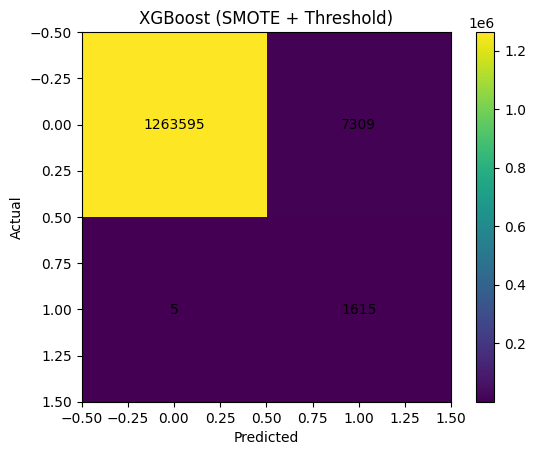

In [35]:
y_probs = xgb_model_smote.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)

evaluate_model("XGBoost (SMOTE + Threshold)", y_test, y_pred_custom)

In [36]:
final_model = xgb_model_smote

joblib.dump(final_model, "xgb_model.pkl")

# Save features
features = X_train.columns.tolist()
joblib.dump(features, "features.pkl")

print("✅ FINAL MODEL SAVED")

✅ FINAL MODEL SAVED


In [37]:
print(features)

['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
